# Matrix Multiplication

*Course notes for **Math for Machine Learning**, C1 · W3 · L2 · V03 — "Matrix Multiplication" (DeepLearning.AI).*

You already know how to multiply a matrix by a vector. Multiplying **two matrices** has a beautiful meaning: it **combines (composes) two linear transformations into a third one**. This lecture covers:

- Matrix product as **composition** of transformations.
- Why the order is **flipped** ($C = B\,A$, second-applied on the left).
- The fast **row $\cdot$ column** dot-product recipe.
- Multiplying **rectangular** matrices and the dimension rules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Multiplication = composing two transformations

Apply two transformations one after the other:

$$ A = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix} \quad\text{(first)}, \qquad B = \begin{pmatrix} 2 & -1 \\ 0 & 2 \end{pmatrix} \quad\text{(second)}. $$

- $A$ sends the basis to $(3,1)$ and $(1,2)$.
- $B$ then acts on *those* vectors: $B(3,1) = (5,2)$ and $B(1,2) = (0,4)$.

Forgetting the middle step, the **overall** map sends $(1,0)\to(5,2)$ and $(0,1)\to(0,4)$ — so (columns = images of the basis) the combined matrix is

$$ C = \begin{pmatrix} 5 & 0 \\ 2 & 4 \end{pmatrix}. $$

In [2]:
A = np.array([[3, 1],
              [1, 2]])
B = np.array([[2, -1],
              [0, 2]])

# apply A first, then B, to each basis vector
for e in [np.array([1, 0]), np.array([0, 1])]:
    print(f'{e}  --A-->  {A @ e}  --B-->  {B @ (A @ e)}')

[1 0]  --A-->  [3 1]  --B-->  [5 2]
[0 1]  --A-->  [1 2]  --B-->  [0 4]


## 2. Order matters: $C = B\,A$ (second $\times$ first)

The combined matrix is the product with the **second** transformation on the **left**:

$$ C = B\,A = \begin{pmatrix} 2 & -1 \\ 0 & 2 \end{pmatrix}\begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix} = \begin{pmatrix} 5 & 0 \\ 2 & 4 \end{pmatrix}. $$

Why flipped? Because transformations act on the vector to their **right**: for input $x$ we compute $B(Ax) = (BA)x$, so $A$ touches $x$ first even though it's written second. **Matrix multiplication is not commutative** — $BA \neq AB$ in general.

In [3]:
C = B @ A
print('C = B @ A =')
print(C)
print()
print('A @ B (the WRONG order) =')
print(A @ B, '  <- different, order matters')

# sanity check: (BA) x  ==  B(A x)
x = np.array([1, 1])
print()
print('(B@A) @ x =', (B @ A) @ x, '   B @ (A @ x) =', B @ (A @ x))

C = B @ A =
[[5 0]
 [2 4]]

A @ B (the WRONG order) =
[[ 6 -1]
 [ 2  3]]   <- different, order matters

(B@A) @ x = [5 6]    B @ (A @ x) = [5 6]


## 3. The fast recipe: rows $\cdot$ columns

No need to draw pictures — each entry of the product is a **dot product** of a **row of the left matrix** with a **column of the right matrix**. Entry $(i, j)$ = (row $i$ of $B$) $\cdot$ (column $j$ of $A$):

$$ C_{11} = (2,-1)\cdot(3,1)=5,\;\; C_{12} = (2,-1)\cdot(1,2)=0,\;\; C_{21} = (0,2)\cdot(3,1)=2,\;\; C_{22} = (0,2)\cdot(1,2)=4. $$

In [4]:
# entry (i, j) = row i of B  dot  column j of A
C_manual = np.array([[B[i] @ A[:, j] for j in range(2)] for i in range(2)])
print('rows-dot-columns  =')
print(C_manual)
print('matches B @ A     :', np.array_equal(C_manual, B @ A))

rows-dot-columns  =
[[5 0]
 [2 4]]
matches B @ A     : True


### Visualizing the composition

The unit square, then its image under $A$, then that image under $B$ — which equals applying $C=BA$ directly.

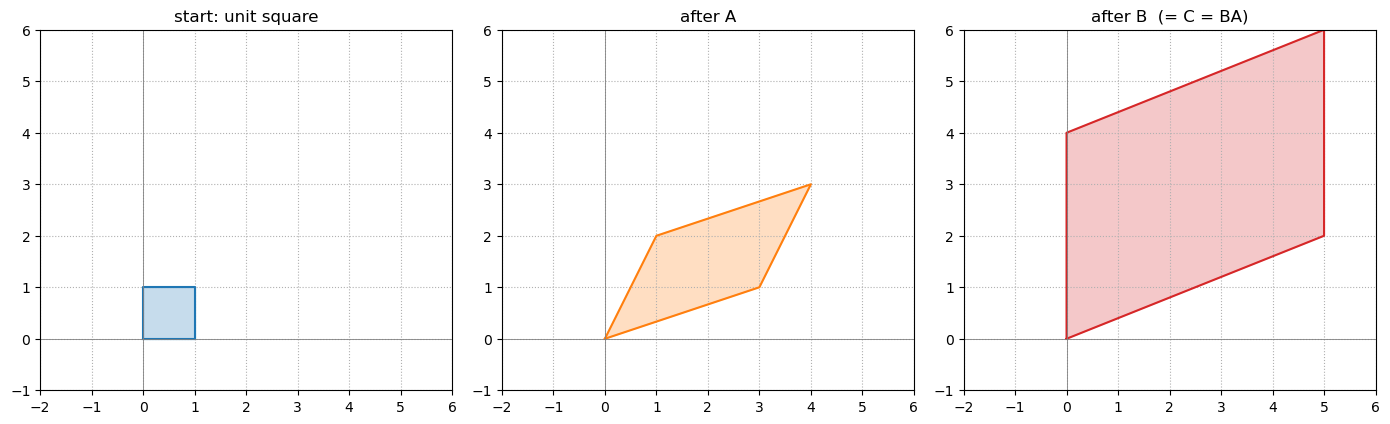

C @ square == B @ (A @ square): True


In [5]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
s1 = A @ square           # after A
s2 = B @ s1               # after B  (== C @ square)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, S, ttl, col in [(axes[0], square, 'start: unit square', 'C0'),
                        (axes[1], s1, 'after A', 'C1'),
                        (axes[2], s2, 'after B  (= C = BA)', 'C3')]:
    ax.fill(S[0], S[1], color=col, alpha=0.25); ax.plot(S[0], S[1], color=col)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl)
    ax.set_xlim(-2, 6); ax.set_ylim(-1, 6)
plt.tight_layout(); plt.show()

print('C @ square == B @ (A @ square):', np.allclose(C @ square, s2))

## 4. Rectangular matrices and the dimension rules

Matrices needn't be square. Here a $2 \times 3$ times a $3 \times 4$ gives a $2 \times 4$ result — each cell is still a (row of the first) $\cdot$ (column of the second):

$$ \underbrace{(2 \times 3)}_{\text{first}} \; \underbrace{(3 \times 4)}_{\text{second}} \longrightarrow \underbrace{(2 \times 4)}_{\text{result}}. $$

**The three rules:**
1. **Inner dimensions must match** — columns of the first $=$ rows of the second ($3 = 3$).
2. The result takes the number of **rows from the first** matrix.
3. The result takes the number of **columns from the second** matrix.

For example, the first row $(3,1,4)$ dotted with the columns of the second matrix gives the top row of the result, and the bottom-left cell is (second row of first) $\cdot$ (first column of second) $= (2,-1,2)\cdot(3,1,-2) = 1$.

In [6]:
P = np.array([[3, 1, 4],
              [2, -1, 2]])          # 2 x 3
Q = np.array([[3, 0, 3, -2],
              [1, 5, 4,  0],
              [-2, 1, 2, 0]])       # 3 x 4

R = P @ Q                            # 2 x 4
print('P shape', P.shape, ' Q shape', Q.shape, ' -> R shape', R.shape)
print('R =')
print(R)
print()
print('top-left  R[0,0] = (3,1,4).(3,1,-2) =', P[0] @ Q[:, 0])   # 2
print('bottom-left R[1,0] = (2,-1,2).(3,1,-2) =', P[1] @ Q[:, 0]) # 1

P shape (2, 3)  Q shape (3, 4)  -> R shape (2, 4)
R =
[[ 2  9 21 -6]
 [ 1 -3  6 -4]]

top-left  R[0,0] = (3,1,4).(3,1,-2) = 2
bottom-left R[1,0] = (2,-1,2).(3,1,-2) = 1


## Summary

- **Matrix multiplication composes linear transformations**: applying $A$ then $B$ is the single matrix $C = B\,A$.
- **Order is flipped and non-commutative**: the second-applied matrix goes on the **left**, because $B(Ax) = (BA)x$; in general $BA \neq AB$.
- **Fast recipe:** entry $(i,j)$ of the product is the **dot product of row $i$ of the left matrix with column $j$ of the right matrix**.
- **Rectangular products:** an $m \times n$ times an $n \times p$ gives an $m \times p$. Inner dimensions must match; the result inherits **rows from the first** and **columns from the second**.
- In NumPy: `B @ A` (or `np.matmul`) — mind the order.